# Mission 1 — Données et analyse exploratoire

**Projet :** prédiction du churn client — Telco Customer Churn
**Objectif de ce notebook :** profiler le jeu de données, vérifier l'absence de fuite,
mesurer le pouvoir discriminant de chaque variable et formuler des hypothèses
vérifiables qui guideront le feature engineering de la Mission 2.

> **Rappel du cadrage (M0)** — métrique principale : coût métier moyen par client
> (C_FN = 350 €, C_FP = 40 €). Aucun modèle n'est entraîné ici.

> **Note de rigueur.** L'exploration porte sur l'ensemble du jeu de données, comme
> le prévoit l'énoncé. Les décisions qui en découlent (features créées, variables
> écartées) seront revalidées en Mission 2 par validation croisée **sur le train
> seul** : aucune statistique apprise ici n'est réutilisée telle quelle.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
pd.set_option("display.width", 120)
sns.set_theme(style="whitegrid")

DATA = "../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(DATA)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 1. Profiling

In [2]:
print(f"Lignes : {df.shape[0]:,}  |  Colonnes : {df.shape[1]}")
print(f"\nValeurs manquantes déclarées (NaN) : {df.isna().sum().sum()}")
df.dtypes.to_frame("dtype")

Lignes : 7,043  |  Colonnes : 21

Valeurs manquantes déclarées (NaN) : 0


,dtype
customerID,str
gender,str
SeniorCitizen,int64
Partner,str
Dependents,str
tenure,int64
PhoneService,str
MultipleLines,str
InternetService,str
OnlineSecurity,str


**Premier constat.** Aucun `NaN` n'est déclaré, et pourtant `TotalCharges` est
typée en texte alors qu'elle devrait être numérique. C'est le signe classique de
valeurs manquantes encodées autrement qu'en `NaN` — ici, par des chaînes vides.

In [3]:
blank = df["TotalCharges"].astype(str).str.strip() == ""
print(f"Chaînes vides dans TotalCharges : {blank.sum()}  ({blank.mean():.2%})")
df.loc[blank, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]]

Chaînes vides dans TotalCharges : 11  (0.16%)


,customerID,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,4472-LVYGI,0,52.55,,Two year,No
753,3115-CZMZD,0,20.25,,Two year,No
936,5709-LVOEQ,0,80.85,,Two year,No
1082,4367-NUYAO,0,25.75,,Two year,No
1340,1371-DWPAZ,0,56.05,,Two year,No
3331,7644-OMVMY,0,19.85,,Two year,No
3826,3213-VVOLG,0,25.35,,Two year,No
4380,2520-SGTTA,0,20.00,,Two year,No
5218,2923-ARZLG,0,19.70,,One year,No
6670,4075-WKNIU,0,73.35,,Two year,No


### Diagnostic de `TotalCharges`

Les 11 valeurs vides partagent **toutes** la même caractéristique : `tenure == 0`.
Ce ne sont donc pas des données perdues, mais des **clients qui viennent de
souscrire** et n'ont pas encore été facturés. Le total facturé vaut logiquement 0.

La conséquence méthodologique est importante : imputer par la **médiane** serait
une erreur de sens — on attribuerait à un nouveau client le montant cumulé d'un
client ancien. L'imputation correcte est **la constante 0**, qui traduit la
réalité métier. C'est de plus une constante, donc sans risque de fuite.

On note aussi que ces 11 clients n'ont **aucun churn** : cohérent, on ne résilie
pas un contrat qu'on vient de signer.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Manquants après conversion :", df["TotalCharges"].isna().sum())
print("tenure des lignes concernées :", df.loc[df["TotalCharges"].isna(), "tenure"].unique())
print("Churn des lignes concernées  :", df.loc[df["TotalCharges"].isna(), "Churn"].unique())

Manquants après conversion : 11
tenure des lignes concernées : [0]
Churn des lignes concernées  : <StringArray>
['No']
Length: 1, dtype: str


### Doublons

In [5]:
print("Doublons stricts (avec customerID) :", df.duplicated().sum())
print("Doublons sans customerID           :", df.drop(columns="customerID").duplicated().sum())
df[df.drop(columns="customerID").duplicated(keep=False)].sort_values("MonthlyCharges").head(4)

Doublons stricts (avec customerID) : 0
Doublons sans customerID           : 22


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
542,2866-IKBTM,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1491,8605-ITULD,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
6774,0970-QXPXW,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No
5170,7721-DVEKZ,Female,0,No,No,1,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.65,19.65,No


**Attention au faux positif.** Aucun doublon strict : les 7 043 `customerID` sont
uniques. En revanche, 22 lignes deviennent identiques si l'on retire l'identifiant.

Il ne faut **pas** les supprimer. Il s'agit de clients réellement distincts qui
partagent le même profil — typiquement de nouveaux abonnés fibre en contrat
mensuel, un segment très homogène. Avec 19 variables dont la plupart sont
binaires, la collision de profils est statistiquement attendue. Les supprimer
reviendrait à jeter de l'information sur un segment surreprésenté.

### Variables quasi-constantes et cardinalité

In [6]:
prof = []
for col in df.columns.drop("customerID"):
    vc = df[col].value_counts(normalize=True)
    prof.append({"variable": col, "n_unique": df[col].nunique(),
                 "modalite_dominante": vc.index[0], "part_dominante": round(vc.iloc[0], 3)})
pd.DataFrame(prof).sort_values("part_dominante", ascending=False)

,variable,n_unique,modalite_dominante,part_dominante
5,PhoneService,2,Yes,0.903
1,SeniorCitizen,2,0,0.838
19,Churn,2,No,0.735
3,Dependents,2,No,0.700
15,PaperlessBilling,2,Yes,0.592
14,Contract,3,Month-to-month,0.550
2,Partner,2,No,0.517
0,gender,2,Male,0.505
8,OnlineSecurity,3,No,0.497
11,TechSupport,3,No,0.493


`PhoneService` est la plus déséquilibrée (90,3 % de « Yes ») sans être
quasi-constante au sens strict (seuil usuel : 95-99 %). Aucune variable n'est à
écarter à ce stade sur ce seul critère.

### Corrélations entre variables numériques

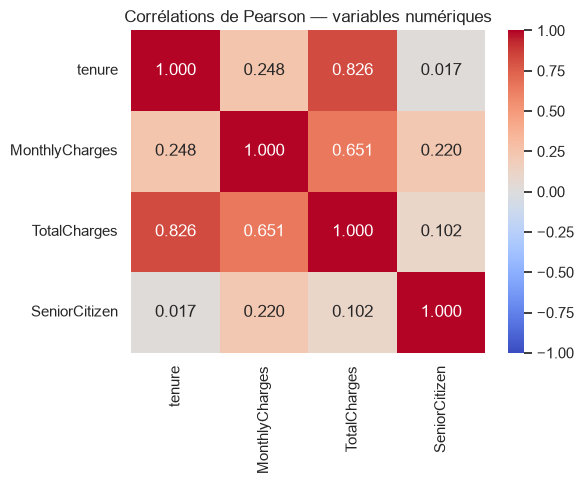

In [7]:
num_cols = ["tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen"]
corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("Corrélations de Pearson — variables numériques")
plt.tight_layout(); plt.show()

In [8]:
# TotalCharges est-elle redondante ?
produit = df["tenure"] * df["MonthlyCharges"]
ok = df["TotalCharges"].notna()
r = np.corrcoef(df.loc[ok, "TotalCharges"], produit[ok])[0, 1]
ecart = ((df.loc[ok, "TotalCharges"] - produit[ok]).abs() / df.loc[ok, "TotalCharges"]).median()
print(f"corr(TotalCharges, tenure × MonthlyCharges) = {r:.4f}")
print(f"Écart relatif médian : {ecart:.2%}")

corr(TotalCharges, tenure × MonthlyCharges) = 0.9996
Écart relatif médian : 2.00%


**Redondance forte.** `TotalCharges` ≈ `tenure` × `MonthlyCharges` à 0,9996 de
corrélation, avec seulement 2 % d'écart médian (dû aux variations tarifaires au
fil du contrat). Elle est donc presque entièrement déterminée par deux autres
variables — corrélation de 0,826 avec `tenure`.

Ce n'est **pas** une fuite : le montant cumulé est connu au moment de la
prédiction. C'est un problème de **multicolinéarité**, qui déstabilisera les
coefficients de la régression logistique sans gêner les modèles à base d'arbres.
À traiter en Mission 2.

## 2. Détection de fuite de données

Une fuite se manifeste par une variable qui prédit la cible « trop parfaitement ».
Le test : mesurer l'AUC de chaque variable prise **seule**. Une valeur proche de
1 signalerait une variable connue seulement après le départ du client.

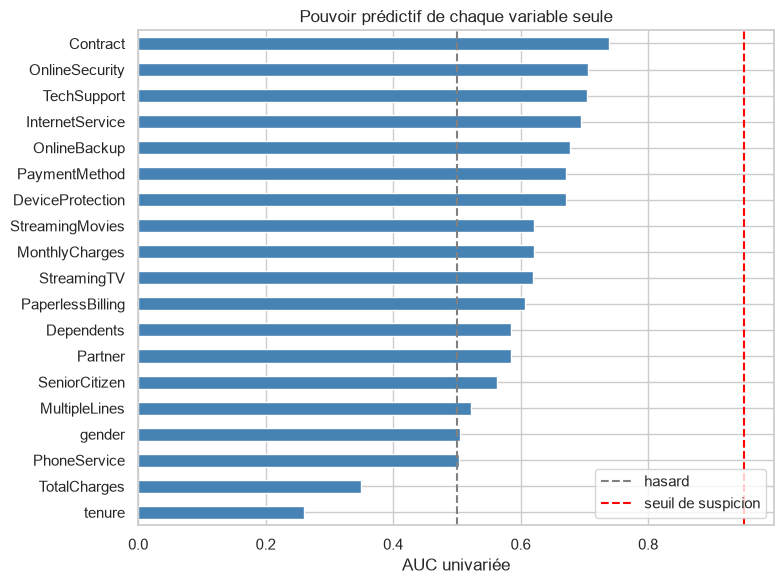

,AUC
Contract,0.739
OnlineSecurity,0.705
TechSupport,0.703
InternetService,0.695
OnlineBackup,0.678
PaymentMethod,0.671
DeviceProtection,0.671
StreamingMovies,0.621
MonthlyCharges,0.621
StreamingTV,0.620


In [9]:
y = (df["Churn"] == "Yes").astype(int)
X = df.drop(columns=["customerID", "Churn"])

auc_uni = {}
for col in X.columns:
    if X[col].dtype.kind in "if":
        score = X[col].fillna(0)
    else:
        score = X[col].map(y.groupby(X[col]).mean())   # taux de churn par modalité
    auc_uni[col] = roc_auc_score(y, score)

auc_s = pd.Series(auc_uni).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
auc_s.sort_values().plot.barh(ax=ax, color="steelblue")
ax.axvline(0.5, color="grey", ls="--", label="hasard")
ax.axvline(0.95, color="red", ls="--", label="seuil de suspicion")
ax.set_xlabel("AUC univariée"); ax.set_title("Pouvoir prédictif de chaque variable seule")
ax.legend(); plt.tight_layout(); plt.show()
auc_s.round(3).to_frame("AUC")

### Conclusion de la vérification

**Aucune fuite détectée.** L'AUC univariée maximale est de **0,740** (`tenure`),
très loin du seuil de suspicion. Aucune variable ne prédit seule la cible de
façon quasi parfaite.

Les variables examinées une à une, du point de vue de leur disponibilité au
moment de la prédiction :

| Variable | Connue avant le départ ? | Verdict |
|---|---|---|
| `tenure`, `Contract`, `MonthlyCharges` | Oui, données contractuelles | Utilisable |
| `TotalCharges` | Oui, facturation courante | Utilisable, mais redondante |
| Variables de services (`OnlineSecurity`…) | Oui, souscriptions actives | Utilisable |
| `PaymentMethod`, `PaperlessBilling` | Oui, paramètres du compte | Utilisable |
| `customerID` | Identifiant sans contenu prédictif | **À exclure** |

`customerID` est retiré non par risque de fuite mais parce qu'un identifiant
unique n'a aucun pouvoir de généralisation, tout en offrant à un modèle flexible
la possibilité de mémoriser le jeu d'entraînement.

**Le vrai risque de fuite de ce projet ne se situe pas ici** : il est dans le
*prétraitement*. Imputer, encoder ou standardiser avant le `train_test_split`
laisserait fuiter des statistiques du test vers le train. C'est l'objet de la
Mission 2.

## 3. Analyse bivariée et pouvoir discriminant

L'**information mutuelle** est utilisée plutôt que la corrélation : elle capte
toute forme de dépendance, y compris non monotone, et s'applique aux variables
catégorielles.

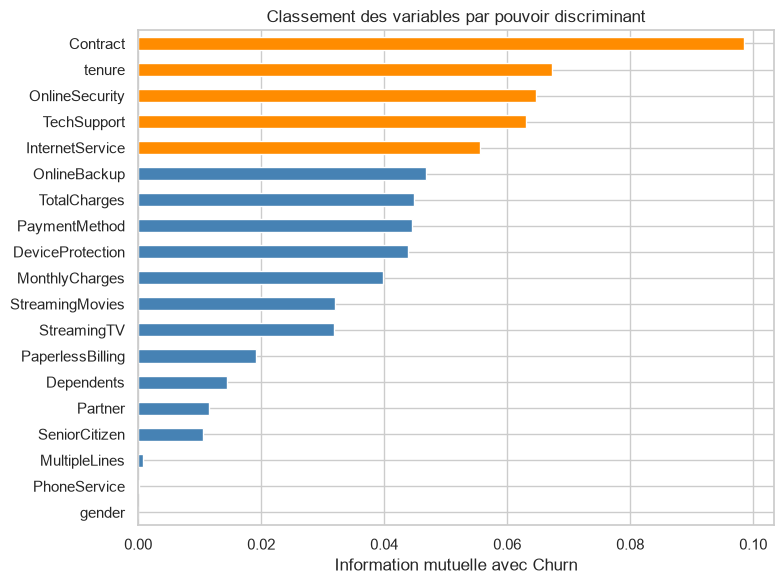

,MI
Contract,0.0985
tenure,0.0673
OnlineSecurity,0.0647
TechSupport,0.0630
InternetService,0.0556
OnlineBackup,0.0468
TotalCharges,0.0448
PaymentMethod,0.0445
DeviceProtection,0.0439
MonthlyCharges,0.0398


In [10]:
X_mi = X.copy()
X_mi["TotalCharges"] = X_mi["TotalCharges"].fillna(0)
cat_cols = X_mi.select_dtypes(exclude="number").columns.tolist()
X_mi[cat_cols] = OrdinalEncoder().fit_transform(X_mi[cat_cols])

discrete = [col in cat_cols or col == "SeniorCitizen" for col in X_mi.columns]
mi = mutual_info_classif(X_mi, y, discrete_features=discrete, random_state=RANDOM_STATE)
mi_s = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["darkorange" if i < 5 else "steelblue" for i in range(len(mi_s))]
mi_s.sort_values().plot.barh(ax=ax, color=colors[::-1])
ax.set_xlabel("Information mutuelle avec Churn")
ax.set_title("Classement des variables par pouvoir discriminant")
plt.tight_layout(); plt.show()
mi_s.round(4).to_frame("MI")

### Les 5 variables les plus prédictives

| Rang | Variable | MI | Lecture métier |
|---|---|---|---|
| 1 | `Contract` | 0,0985 | L'engagement contractuel est le premier frein au départ |
| 2 | `tenure` | 0,0673 | Le risque se concentre sur les premiers mois |
| 3 | `OnlineSecurity` | 0,0647 | Les services annexes ancrent le client |
| 4 | `TechSupport` | 0,0630 | Idem — et sépare aussi les abonnés Internet des autres |
| 5 | `InternetService` | 0,0556 | La fibre concentre l'insatisfaction |

À l'autre extrémité, `gender` (MI ≈ 0,0000 ; AUC 0,505) et `PhoneService`
(AUC 0,504) sont indiscernables du hasard. Le cas de `gender` est doublement
intéressant : c'est un attribut protégé, **sans aucun pouvoir prédictif**. Son
exclusion satisfait donc à la fois la performance et l'équité — argument repris
dans la question de réflexion n° 4.

## 4. Vérification graphique des hypothèses

### H1 — Les clients en contrat mensuel churnent davantage que les engagés

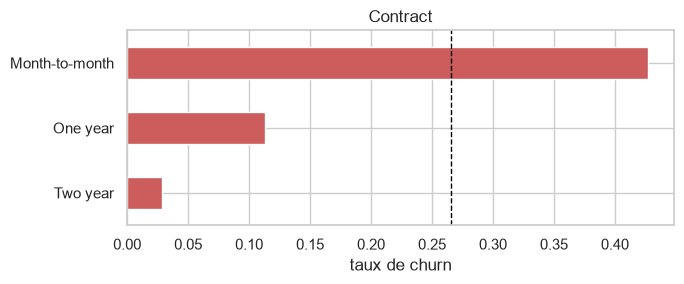

,taux_churn,effectif
Contract,,
Month-to-month,0.427097,3875
One year,0.112695,1473
Two year,0.028319,1695


In [11]:
def taux_churn(col):
    t = pd.DataFrame({"taux_churn": y.groupby(df[col]).mean(),
                      "effectif": df[col].value_counts()})
    return t.sort_values("taux_churn", ascending=False)

def plot_taux(col, ax):
    t = taux_churn(col).sort_values("taux_churn")
    t["taux_churn"].plot.barh(ax=ax, color="indianred")
    ax.axvline(y.mean(), color="black", ls="--", lw=1)
    ax.set_xlabel("taux de churn"); ax.set_ylabel(""); ax.set_title(col)

fig, ax = plt.subplots(figsize=(7, 3))
plot_taux("Contract", ax)
plt.tight_layout(); plt.show()
taux_churn("Contract")

**Validée, et massivement.** 42,7 % de churn en contrat mensuel contre 2,8 % en
engagement deux ans — un facteur **15**. Ce seul écart explique pourquoi
`Contract` domine le classement. Rappel du cadrage : 55 % du parc est en contrat
mensuel, donc le segment à risque est aussi le plus gros.

### H2 — Le risque de départ se concentre sur les premiers mois d'ancienneté

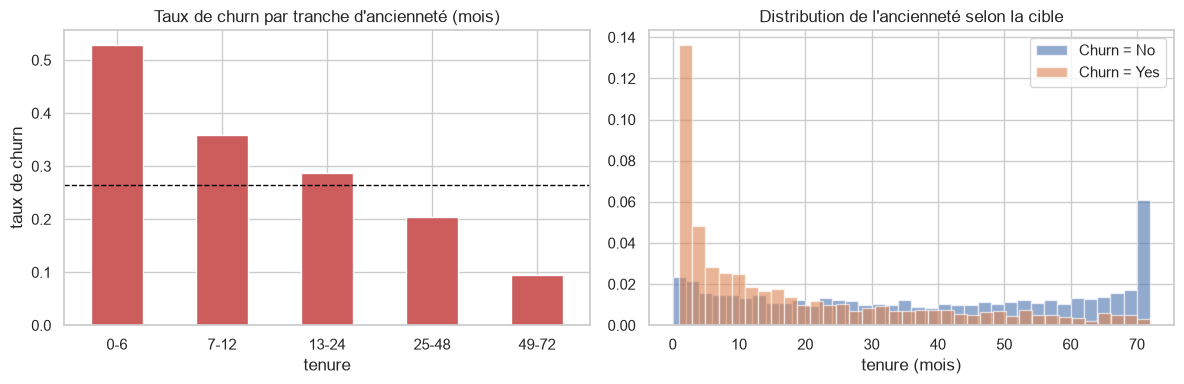

,taux_churn,effectif
tenure,,
0-6,0.529372,1481
7-12,0.358865,705
13-24,0.287109,1024
25-48,0.203890,1594
49-72,0.095132,2239


In [12]:
tranches = pd.cut(df["tenure"], [-1, 6, 12, 24, 48, 72],
                  labels=["0-6", "7-12", "13-24", "25-48", "49-72"])
t = pd.DataFrame({"taux_churn": y.groupby(tranches, observed=True).mean(),
                  "effectif": tranches.value_counts().sort_index()})

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
t["taux_churn"].plot.bar(ax=axes[0], color="indianred", rot=0)
axes[0].axhline(y.mean(), color="black", ls="--", lw=1)
axes[0].set_title("Taux de churn par tranche d'ancienneté (mois)"); axes[0].set_ylabel("taux de churn")
for label, grp in df.groupby(df["Churn"]):
    axes[1].hist(grp["tenure"], bins=36, alpha=0.6, label=f"Churn = {label}", density=True)
axes[1].set_title("Distribution de l'ancienneté selon la cible")
axes[1].set_xlabel("tenure (mois)"); axes[1].legend()
plt.tight_layout(); plt.show()
t

**Validée.** 52,9 % de churn sur les six premiers mois, contre 9,5 % au-delà de
quatre ans. La relation est monotone décroissante. L'histogramme montre deux
populations distinctes : les partants se massent aux faibles anciennetés, les
fidèles s'accumulent au plafond de 72 mois.

Conséquence directe pour la Mission 2 : une **ancienneté catégorisée** est une
candidate naturelle au feature engineering, la relation n'étant pas linéaire.

### H3 — Les abonnés fibre optique churnent plus que les abonnés DSL

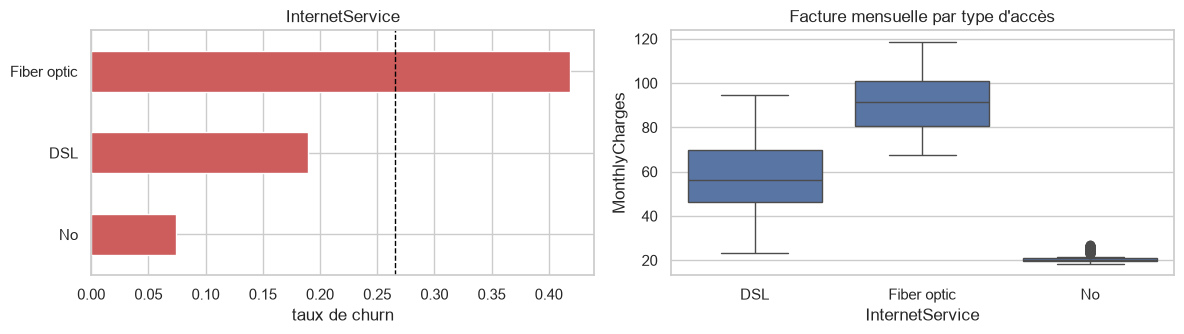

,taux_churn,effectif
InternetService,,
Fiber optic,0.418928,3096
DSL,0.189591,2421
No,0.074050,1526


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_taux("InternetService", axes[0])
sns.boxplot(data=df, x="InternetService", y="MonthlyCharges", ax=axes[1])
axes[1].set_title("Facture mensuelle par type d'accès")
plt.tight_layout(); plt.show()
taux_churn("InternetService")

**Validée, mais l'explication n'est pas celle qu'on croit.** La fibre churne à
41,9 % contre 19,0 % en DSL. Le boxplot révèle le mécanisme sous-jacent : la
fibre est nettement plus chère. L'hypothèse plausible est un **rapport
qualité-prix perçu défavorable** plutôt qu'un défaut technique — les clients les
plus facturés sont aussi les plus volatils.

À noter : la modalité « No » (pas d'Internet) churne à 7,4 %, le plus bas du jeu
de données. Ces 1 526 clients ne souscrivent que la téléphonie et sont très
stables.

### H4 — Le paiement par chèque électronique signale un risque accru

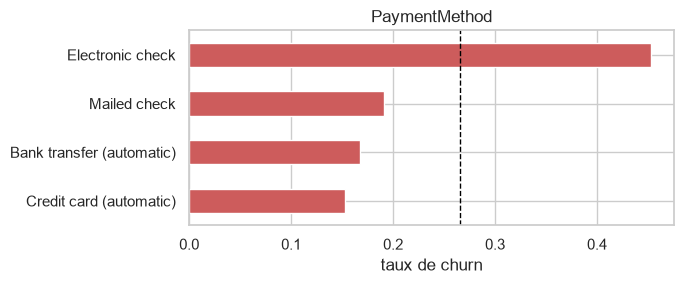

,taux_churn,effectif
PaymentMethod,,
Electronic check,0.452854,2365
Mailed check,0.191067,1612
Bank transfer (automatic),0.167098,1544
Credit card (automatic),0.152431,1522


In [14]:
fig, ax = plt.subplots(figsize=(7, 3))
plot_taux("PaymentMethod", ax)
plt.tight_layout(); plt.show()
taux_churn("PaymentMethod")

**Validée.** 45,3 % de churn pour le chèque électronique, contre 15-17 % pour
les prélèvements automatiques. L'interprétation est comportementale : un moyen de
paiement automatique crée une **friction de sortie** (il faut une démarche pour
l'annuler) et signale un engagement plus durable, là où le paiement manuel
suppose une décision renouvelée à chaque échéance.

### H5 — L'absence de services de support fidélisants accroît le risque

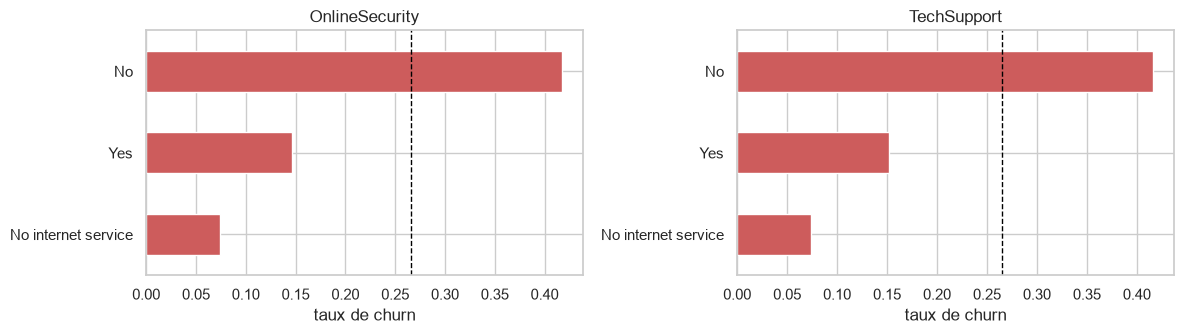

taux_churn  effectif
variable       OnlineSecurity                           
OnlineSecurity No                     0.417667      3498
               Yes                    0.146112      2019
               No internet service    0.074050      1526
TechSupport    No                     0.416355      3473
               Yes                    0.151663      2044
               No internet service    0.074050      1526

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_taux("OnlineSecurity", axes[0])
plot_taux("TechSupport", axes[1])
plt.tight_layout(); plt.show()
pd.concat({"OnlineSecurity": taux_churn("OnlineSecurity"),
           "TechSupport": taux_churn("TechSupport")}, names=["variable"])

**Validée.** Parmi les abonnés Internet, l'absence de sécurité en ligne fait
passer le churn de 14,6 % à 41,8 % ; le support technique donne le même profil
(15,2 % contre 41,6 %).

**Piège d'encodage à signaler.** Ces variables ont trois modalités, dont
« No internet service ». Vérification faite, les 1 526 clients concernés sont
exactement ceux dont `InternetService == "No"` : **six colonnes encodent donc la
même information de façon redondante**. C'est une piste directe de feature
engineering — compter le nombre de services réellement souscrits.

In [16]:
services = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
            "TechSupport", "StreamingTV", "StreamingMovies"]
sans_net = (df[services] == "No internet service").all(axis=1)
print(f"Clients 'No internet service' sur les 6 colonnes : {sans_net.sum()}")
print(f"Clients avec InternetService == 'No'            : {(df['InternetService'] == 'No').sum()}")
print(f"Les deux ensembles coïncident : {sans_net.equals(df['InternetService'] == 'No')}")

nb_services = (df[services] == "Yes").sum(axis=1)
t = pd.DataFrame({"taux_churn": y.groupby(nb_services).mean().round(3),
                  "effectif": nb_services.value_counts().sort_index()})
t.index.name = "nb_services_souscrits"
t

Clients 'No internet service' sur les 6 colonnes : 1526
Clients avec InternetService == 'No'            : 1526
Les deux ensembles coïncident : True


,taux_churn,effectif
nb_services_souscrits,,
0,0.214,2219
1,0.458,966
2,0.358,1033
3,0.274,1118
4,0.223,852
5,0.124,571
6,0.053,284


## 5. Synthèse — les trois insights majeurs

**1. L'engagement contractuel est le déterminant principal du churn.**
Le contrat mensuel affiche 42,7 % de churn contre 2,8 % en engagement deux ans,
et `Contract` domine le classement par information mutuelle. Comme 55 % du parc
est en mensuel, le segment le plus risqué est aussi le plus nombreux. *Levier
métier : l'offre de rétention la plus rentable est probablement une incitation à
passer sur un contrat engageant, pas une simple remise.*

**2. Le risque est concentré sur les premiers mois, de façon non linéaire.**
52,9 % de churn sur les six premiers mois, 9,5 % au-delà de quatre ans. La
relation décroît fortement puis se stabilise, ce qui justifie de créer une
ancienneté catégorisée plutôt que de laisser `tenure` brute au modèle linéaire.

**3. Le prix perçu, plus que le service lui-même, alimente le départ.**
La fibre — l'offre la plus chère — churne à 41,9 %, et l'absence de services
d'accompagnement (sécurité, support) triple le risque. Le client vulnérable type
paie cher, n'a pas de services annexes, et n'est retenu par aucun engagement.

### Hypothèses retenues pour la Mission 2

Les cinq hypothèses sont validées graphiquement. Elles orientent trois pistes de
feature engineering, dont le gain réel devra être **mesuré par validation croisée
sur le train seul** :

- **Ancienneté catégorisée** — la relation `tenure`/churn n'est pas linéaire (H2).
- **Nombre de services souscrits** — six colonnes encodent une information
  redondante et ordonnable (H5).
- **Ratio charges / ancienneté** — approche le prix perçu, moteur commun à H3.

### Points de vigilance transmis à la Mission 2

- `TotalCharges` : imputer par la **constante 0** (nouveaux clients), jamais par
  la médiane ; et surveiller la multicolinéarité avec `tenure` × `MonthlyCharges`.
- `customerID` : à exclure des features.
- `gender` : sans pouvoir prédictif et attribut protégé — son exclusion sert la
  performance comme l'équité.
- Ne pas supprimer les 22 « doublons » sans identifiant : ce sont des clients
  distincts au profil identique.